In [1]:
import pandas as pd

df_clean = pd.read_csv(
    "../data/processed/tickets_clean.csv",
    parse_dates=[
        "Date MAJ",
        "Date de résolution",
        "Date/Heure de création"
    ]
)

print(df_clean.shape)

(8141, 11)


In [3]:
import pandas as pd

df_clean = pd.read_csv(
    "../data/processed/tickets_clean.csv",
    parse_dates=[
        "Date MAJ",
        "Date de résolution",
        "Date/Heure de création"
    ]
)

print(df_clean.shape)

(8141, 11)


In [3]:
import pandas as pd

df_clean = pd.read_csv("../data/processed/tickets_clean.csv")

print(df_clean.shape)

(8141, 11)


In [4]:
sla_par_priorite = {"Critique (P1)": 3, "Élevée (P2)": 8, "Moyenne (P3)": 64, "Faible (P4)": 90}

df_clean["SLA_cible_heures"] = df_clean["Priorité"].map(sla_par_priorite)

df_clean["SLA_respecte"] = (
df_clean["Temps_resolution_heures"].notna()
& (df_clean["Temps_resolution_heures"] <= df_clean["SLA_cible_heures"])
)

print(df_clean[["Priorité", "Temps_resolution_heures", "SLA_cible_heures", "SLA_respecte"]].head(20))

        Priorité  Temps_resolution_heures  SLA_cible_heures  SLA_respecte
0    Faible (P4)                72.414991              90.0          True
1    Faible (P4)                      NaN              90.0         False
2   Moyenne (P3)                      NaN              64.0         False
3    Faible (P4)               172.086516              90.0         False
4    Faible (P4)               325.951153              90.0         False
5    Faible (P4)                      NaN              90.0         False
6    Faible (P4)               152.364185              90.0         False
7    Faible (P4)                12.077503              90.0          True
8   Moyenne (P3)                21.763051              64.0          True
9    Faible (P4)               109.761130              90.0         False
10  Moyenne (P3)                 6.238277              64.0          True
11   Faible (P4)                93.837785              90.0         False
12  Moyenne (P3)                 1.258

In [5]:
sla_respecte = df_clean["SLA_respecte"].sum()

tickets_avec_sla = df_clean["Temps_resolution_heures"].notna().sum()

taux_sla = sla_respecte / tickets_avec_sla * 100

print("Tickets résolus :", tickets_avec_sla)
print("Tickets respectant le SLA :", sla_respecte)
print("Taux de respect du SLA :", round(taux_sla, 2), "%")

Tickets résolus : 5624
Tickets respectant le SLA : 3565
Taux de respect du SLA : 63.39 %


In [6]:
sla_par_priorite_resultat = df_clean[df_clean["Temps_resolution_heures"].notna()].groupby("Priorité")["SLA_respecte"].mean() * 100

print(sla_par_priorite_resultat.sort_values(ascending=False).round(2))

Priorité
Faible (P4)      69.75
Moyenne (P3)     57.35
Élevée (P2)      29.55
Critique (P1)     5.56
Inconnu           0.00
Name: SLA_respecte, dtype: float64


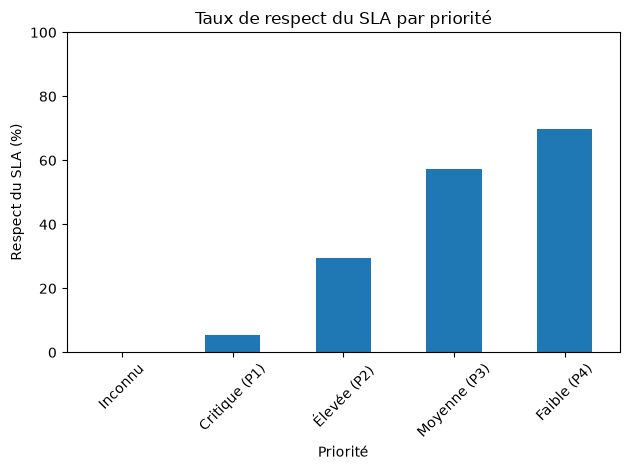

In [9]:
import matplotlib.pyplot as plt
sla_par_priorite_resultat.sort_values().plot(kind="bar")

plt.title("Taux de respect du SLA par priorité")
plt.xlabel("Priorité")
plt.ylabel("Respect du SLA (%)")
plt.ylim(0, 100)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

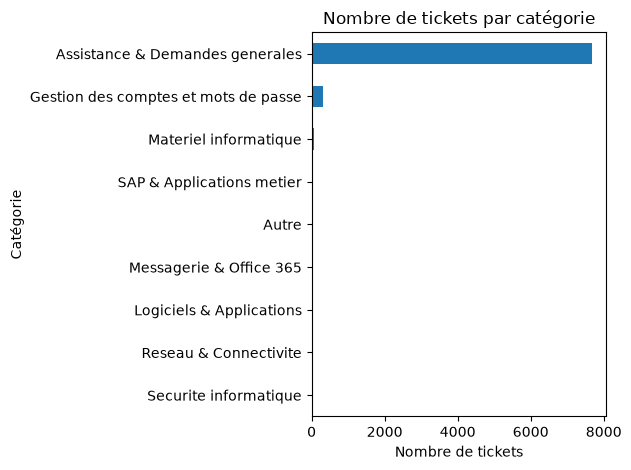

In [10]:
import matplotlib.pyplot as plt

categorie_counts = df_clean["Categorie"].value_counts()

categorie_counts.sort_values().plot(kind="barh")

plt.title("Nombre de tickets par catégorie")
plt.xlabel("Nombre de tickets")
plt.ylabel("Catégorie")
plt.tight_layout()
plt.show()

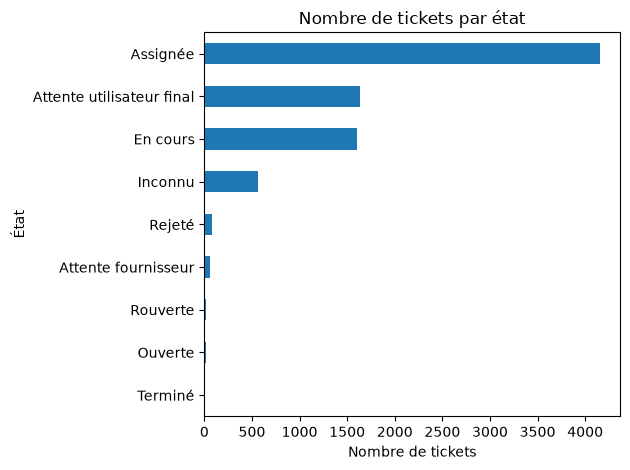

In [11]:
import matplotlib.pyplot as plt

etat_counts = df_clean["État"].value_counts()

etat_counts.sort_values().plot(kind="barh")

plt.title("Nombre de tickets par état")
plt.xlabel("Nombre de tickets")
plt.ylabel("État")
plt.tight_layout()
plt.show()

In [ ]:
df_clean.head()

,ticket_id,État,ID de phase,Priorité,Titre de la demande,Demandé pour Nom,Date MAJ,Date de résolution,Date/Heure de création,Categorie,Temps_resolution_heures
0,3,En cours,Fulfill,Faible (P4),Demande de service,Ayman El Idrissi,2026-03-18 09:18:55.978,2026-02-13 14:20:20,2026-02-10 13:55:26.031,Assistance & Demandes generales,72.414991
1,4,Attente utilisateur final,Fulfill,Faible (P4),Demande de service,Widad Tahiri,2026-03-12 10:17:36.423,NaT,2026-03-03 09:57:49.939,Assistance & Demandes generales,NaN
2,5,Attente utilisateur final,Fulfill,Moyenne (P3),Demande de service,Hassan Belkadi,2026-02-20 09:19:59.298,NaT,2025-09-23 17:16:53.268,Assistance & Demandes generales,NaN
3,6,Attente utilisateur final,Fulfill,Faible (P4),Demande de service,Loubna Benjelloun,2026-03-25 11:11:14.946,2026-02-13 20:13:48,2026-02-06 16:08:36.542,Assistance & Demandes generales,172.086516
4,7,Attente utilisateur final,Fulfill,Faible (P4),Demande de service,Aziz Berrada,2026-03-11 15:15:59.620,2026-02-20 06:03:17,2026-02-06 16:06:12.849,Assistance & Demandes generales,325.951153


In [ ]:
total_tickets = len(df_clean)

tickets_resolus = df_clean["Date de résolution"].notna().sum()

taux_resolution = tickets_resolus / total_tickets * 100

print("Total tickets :", total_tickets)
print("Tickets résolus :", tickets_resolus)
print("Taux de résolution :", round(taux_resolution, 2), "%")

Total tickets : 8141
Tickets résolus : 5624
Taux de résolution : 69.08 %


In [ ]:
tickets_non_resolus = df_clean["Date de résolution"].isna().sum()

taux_non_resolution = tickets_non_resolus / total_tickets * 100

print("Tickets non résolus :", tickets_non_resolus)
print("Taux de non-résolution :", round(taux_non_resolution, 2), "%")

Tickets non résolus : 2517
Taux de non-résolution : 30.92 %


In [ ]:
mttr = df_clean["Temps_resolution_heures"].mean()

print("MTTR :", round(mttr, 2), "heures")
print("MTTR :", round(mttr / 24, 2), "jours")

MTTR : 88.29 heures
MTTR : 3.68 jours


In [ ]:
tickets_rouverts = (df_clean["État"] == "Rouverte").sum()

taux_reouverture = tickets_rouverts / total_tickets * 100

print("Tickets rouverts :", tickets_rouverts)
print("Taux de réouverture :", round(taux_reouverture, 2), "%")

Tickets rouverts : 16
Taux de réouverture : 0.2 %


In [ ]:
tickets_escalades = (df_clean["ID de phase"] == "Escalate").sum()

taux_escalade = tickets_escalades / total_tickets * 100

print("Tickets escaladés :", tickets_escalades)
print("Taux d'escalade :", round(taux_escalade, 2), "%")

Tickets escaladés : 1428
Taux d'escalade : 17.54 %


In [ ]:
SLA_HEURES = 48

tickets_sla = df_clean["Temps_resolution_heures"].notna()

tickets_sla_respecte = (
    tickets_sla &
    (df_clean["Temps_resolution_heures"] <= SLA_HEURES)
)

tickets_sla_depasse = (
    tickets_sla &
    (df_clean["Temps_resolution_heures"] > SLA_HEURES)
)

nb_sla_respecte = tickets_sla_respecte.sum()
nb_sla_depasse = tickets_sla_depasse.sum()

print("SLA cible :", SLA_HEURES, "heures")
print("Tickets résolus dans le SLA :", nb_sla_respecte)
print("Tickets résolus hors SLA :", nb_sla_depasse)

SLA cible : 48 heures
Tickets résolus dans le SLA : 2699
Tickets résolus hors SLA : 2925


In [ ]:
taux_sla = nb_sla_respecte / tickets_resolus * 100

print("Taux de respect du SLA :", round(taux_sla, 2), "%")

Taux de respect du SLA : 47.99 %


In [ ]:
df_clean["Priorité"].value_counts()

Priorité
Faible (P4)      6942
Inconnu           557
Moyenne (P3)      479
Critique (P1)     114
Élevée (P2)        49
Name: count, dtype: int64

In [ ]:
resolution_par_priorite = (
    df_clean.groupby("Priorité")["Date de résolution"]
    .apply(lambda x: x.notna().mean() * 100)
    .round(2)
    .sort_values(ascending=False)
)

print(resolution_par_priorite)

Priorité
Élevée (P2)      89.80
Moyenne (P3)     70.98
Faible (P4)      69.25
Inconnu          64.81
Critique (P1)    63.16
Name: Date de résolution, dtype: float64


In [ ]:
mttr_par_priorite = (
    df_clean.groupby("Priorité")["Temps_resolution_heures"]
    .mean()
    .round(2)
    .sort_values()
)

print(mttr_par_priorite)

Priorité
Critique (P1)     74.85
Élevée (P2)       80.00
Inconnu           83.66
Faible (P4)       87.07
Moyenne (P3)     114.40
Name: Temps_resolution_heures, dtype: float64


In [ ]:
df_clean["Categorie"].value_counts()

Categorie
Assistance & Demandes generales         7686
Gestion des comptes et mots de passe     312
Materiel informatique                     68
SAP & Applications metier                 21
Messagerie & Office 365                   19
Autre                                     19
Logiciels & Applications                  10
Reseau & Connectivite                      5
Securite informatique                      1
Name: count, dtype: int64

In [ ]:
resolution_par_categorie = (
    df_clean.groupby("Categorie")["Date de résolution"]
    .apply(lambda x: x.notna().mean() * 100)
    .round(2)
    .sort_values(ascending=False)
)

print(resolution_par_categorie)

Categorie
Securite informatique                   100.00
Autre                                    89.47
Reseau & Connectivite                    80.00
Logiciels & Applications                 80.00
Gestion des comptes et mots de passe     73.08
Materiel informatique                    70.59
Assistance & Demandes generales          68.85
SAP & Applications metier                66.67
Messagerie & Office 365                  63.16
Name: Date de résolution, dtype: float64


In [ ]:
mttr_par_categorie = (
    df_clean.groupby("Categorie")["Temps_resolution_heures"]
    .mean()
    .round(2)
    .sort_values()
)

print(mttr_par_categorie)

Categorie
Autre                                    33.47
Messagerie & Office 365                  65.80
Materiel informatique                    82.67
Assistance & Demandes generales          86.55
SAP & Applications metier                86.64
Securite informatique                    97.50
Logiciels & Applications                101.47
Reseau & Connectivite                   123.27
Gestion des comptes et mots de passe    134.12
Name: Temps_resolution_heures, dtype: float64


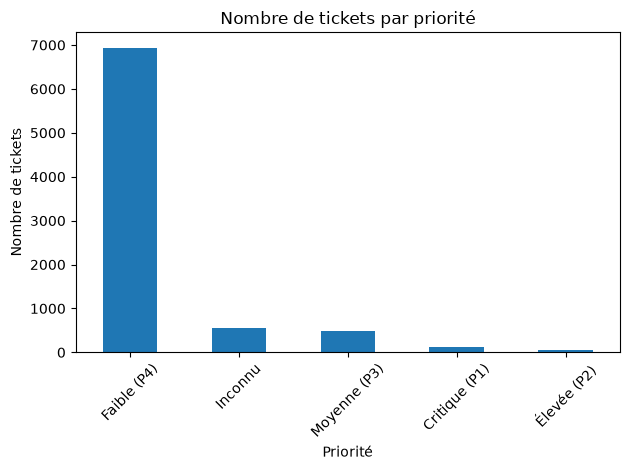

In [ ]:
import matplotlib.pyplot as plt

priorite_counts = df_clean["Priorité"].value_counts()

priorite_counts.plot(kind="bar")

plt.title("Nombre de tickets par priorité")
plt.xlabel("Priorité")
plt.ylabel("Nombre de tickets")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
categorie_counts = df_clean["Categorie"].value_counts()

print(categorie_counts)

Categorie
Assistance & Demandes generales         7686
Gestion des comptes et mots de passe     312
Materiel informatique                     68
SAP & Applications metier                 21
Messagerie & Office 365                   19
Autre                                     19
Logiciels & Applications                  10
Reseau & Connectivite                      5
Securite informatique                      1
Name: count, dtype: int64


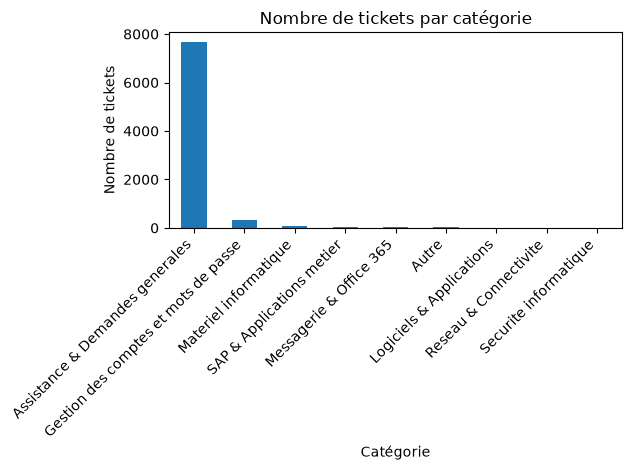

In [ ]:
import matplotlib.pyplot as plt

categorie_counts = df_clean["Categorie"].value_counts()

categorie_counts.plot(kind="bar")

plt.title("Nombre de tickets par catégorie")
plt.xlabel("Catégorie")
plt.ylabel("Nombre de tickets")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

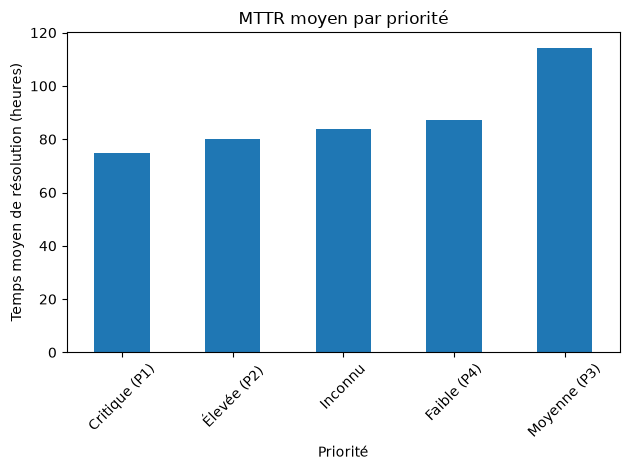

In [ ]:
import matplotlib.pyplot as plt

mttr_par_priorite = (
    df_clean.groupby("Priorité")["Temps_resolution_heures"]
    .mean()
    .sort_values()
)

mttr_par_priorite.plot(kind="bar")

plt.title("MTTR moyen par priorité")
plt.xlabel("Priorité")
plt.ylabel("Temps moyen de résolution (heures)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
df_clean["Priorité"].value_counts()

Priorité
Faible (P4)      6942
Inconnu           557
Moyenne (P3)      479
Critique (P1)     114
Élevée (P2)        49
Name: count, dtype: int64

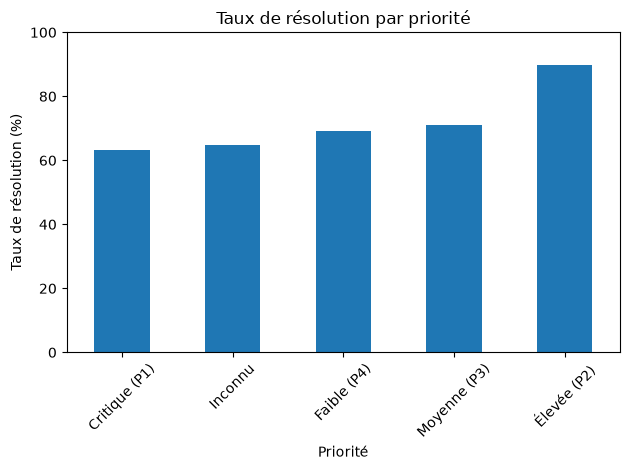

In [4]:
import matplotlib.pyplot as plt

resolution_par_priorite = (
    df_clean.groupby("Priorité")["Date de résolution"]
    .apply(lambda x: x.notna().mean() * 100)
    .sort_values()
)

resolution_par_priorite.plot(kind="bar")

plt.title("Taux de résolution par priorité")
plt.xlabel("Priorité")
plt.ylabel("Taux de résolution (%)")
plt.xticks(rotation=45)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

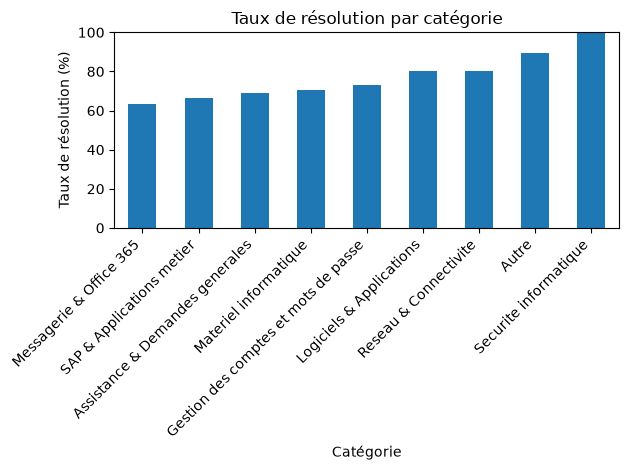

In [5]:
resolution_par_categorie = (
    df_clean.groupby("Categorie")["Date de résolution"]
    .apply(lambda x: x.notna().mean() * 100)
    .sort_values()
)

resolution_par_categorie.plot(kind="bar")

plt.title("Taux de résolution par catégorie")
plt.xlabel("Catégorie")
plt.ylabel("Taux de résolution (%)")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

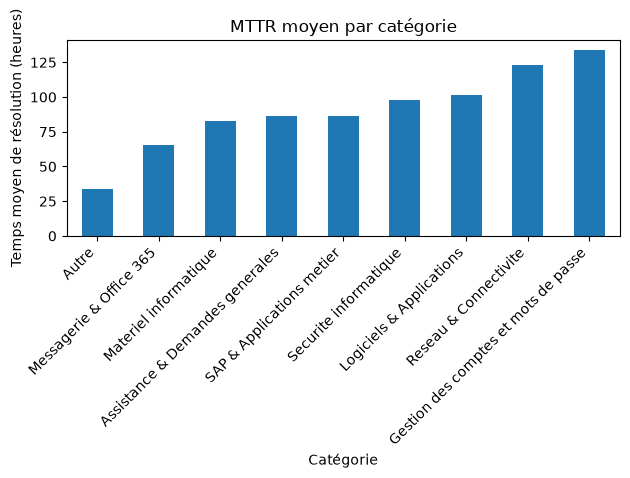

In [6]:
mttr_par_categorie = (
    df_clean.groupby("Categorie")["Temps_resolution_heures"]
    .mean()
    .sort_values()
)

mttr_par_categorie.plot(kind="bar")

plt.title("MTTR moyen par catégorie")
plt.xlabel("Catégorie")
plt.ylabel("Temps moyen de résolution (heures)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [7]:
total_tickets = len(df_clean)

tickets_resolus = df_clean["Date de résolution"].notna().sum()

tickets_non_resolus = df_clean["Date de résolution"].isna().sum()

taux_resolution = tickets_resolus / total_tickets * 100

taux_non_resolution = tickets_non_resolus / total_tickets * 100

mttr = df_clean["Temps_resolution_heures"].mean()

tickets_rouverts = (df_clean["État"] == "Rouverte").sum()

taux_reouverture = tickets_rouverts / total_tickets * 100

tickets_escalades = (df_clean["ID de phase"] == "Escalate").sum()

taux_escalade = tickets_escalades / total_tickets * 100


print("===== KPI HELPDESK =====")
print("Total tickets :", total_tickets)
print("Tickets résolus :", tickets_resolus)
print("Taux de résolution :", round(taux_resolution, 2), "%")
print("Tickets non résolus :", tickets_non_resolus)
print("Taux de non-résolution :", round(taux_non_resolution, 2), "%")
print("MTTR :", round(mttr, 2), "heures")
print("Tickets rouverts :", tickets_rouverts)
print("Taux de réouverture :", round(taux_reouverture, 2), "%")
print("Tickets escaladés :", tickets_escalades)
print("Taux d'escalade :", round(taux_escalade, 2), "%")

===== KPI HELPDESK =====
Total tickets : 8141
Tickets résolus : 5624
Taux de résolution : 69.08 %
Tickets non résolus : 2517
Taux de non-résolution : 30.92 %
MTTR : 88.29 heures
Tickets rouverts : 16
Taux de réouverture : 0.2 %
Tickets escaladés : 1428
Taux d'escalade : 17.54 %
